# 02 — TSF Parser and Initial Preprocessing

This notebook implements a reusable parser for `.tsf` forecasting datasets from the Time Series PILE forecasting subset.

Objectives:
- Parse metadata from `.tsf` files
- Extract time series records into structured format
- Convert parsed data into pandas DataFrames
- Prepare a common representation for downstream forecasting experiments

In [1]:
from pathlib import Path
from pprint import pprint
from datetime import datetime

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

print("Imports loaded successfully.")

Imports loaded successfully.


In [2]:
# Update this path if needed
tsf_file_path = Path(
    "/Users/kunalgurung/.cache/huggingface/hub/datasets--AutonLab--Timeseries-PILE/snapshots/ea89753da2b451928436adb333c7a2e892461c7d/forecasting/monash/m3_yearly_dataset.tsf"
)

print("TSF file exists:", tsf_file_path.exists())
print("TSF file:", tsf_file_path)

TSF file exists: True
TSF file: /Users/kunalgurung/.cache/huggingface/hub/datasets--AutonLab--Timeseries-PILE/snapshots/ea89753da2b451928436adb333c7a2e892461c7d/forecasting/monash/m3_yearly_dataset.tsf


In [3]:
def parse_frequency(freq_text: str):
    """
    Map TSF frequency text to pandas date frequency where possible.
    """
    if freq_text is None:
        return None

    freq_text = freq_text.strip().lower()

    mapping = {
        "yearly": "YS",
        "annual": "YS",
        "quarterly": "QS",
        "monthly": "MS",
        "weekly": "W",
        "daily": "D",
        "hourly": "H",
        "minutely": "T",
        "10_minutes": "10T",
        "half_hourly": "30T",
        "4_seconds": "4S",
        "seconds": "S",
    }

    return mapping.get(freq_text, None)


def parse_bool(text: str):
    """
    Parse TSF boolean metadata fields.
    """
    text = text.strip().lower()
    if text == "true":
        return True
    if text == "false":
        return False
    return text


def parse_scalar_value(raw_value: str, declared_type: str):
    """
    Parse metadata/attribute values according to TSF declared type.
    """
    if raw_value == "?":
        return None

    declared_type = declared_type.lower().strip()

    if declared_type == "numeric":
        try:
            return float(raw_value)
        except ValueError:
            return raw_value

    if declared_type == "integer":
        try:
            return int(raw_value)
        except ValueError:
            return raw_value

    if declared_type == "date":
        # Common Monash TSF format: 1972-01-01 00-00-00
        for fmt in ("%Y-%m-%d %H-%M-%S", "%Y-%m-%d %H:%M:%S", "%Y-%m-%d"):
            try:
                return datetime.strptime(raw_value, fmt)
            except ValueError:
                continue
        return raw_value

    # string or fallback
    return raw_value


def parse_series_values(series_text: str):
    """
    Parse comma-separated time series values.
    """
    values = []
    for item in series_text.split(","):
        item = item.strip()

        if item == "?":
            values.append(np.nan)
        else:
            try:
                values.append(float(item))
            except ValueError:
                values.append(np.nan)

    return values

In [4]:
def parse_tsf_file(file_path: Path):
    """
    Parse a Monash-style .tsf file.

    Returns
    -------
    metadata : dict
        File-level metadata such as frequency, horizon, missing, equallength.
    attribute_defs : list of tuple
        Attribute definitions in the order declared in the file.
        Example: [("series_name", "string"), ("start_timestamp", "date")]
    records_df : pd.DataFrame
        One row per time series. Contains metadata columns + 'series_values'.
    """
    metadata = {}
    attribute_defs = []
    records = []

    in_data_section = False

    with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
        for raw_line in f:
            line = raw_line.strip()

            # Skip empty lines and comments
            if not line or line.startswith("#"):
                continue

            # Metadata and schema
            if not in_data_section:
                lower_line = line.lower()

                if lower_line.startswith("@attribute"):
                    parts = line.split()
                    if len(parts) >= 3:
                        attr_name = parts[1].strip()
                        attr_type = parts[2].strip()
                        attribute_defs.append((attr_name, attr_type))
                    continue

                if lower_line.startswith("@frequency"):
                    metadata["frequency"] = line.split(maxsplit=1)[1].strip()
                    continue

                if lower_line.startswith("@horizon"):
                    metadata["horizon"] = int(line.split(maxsplit=1)[1].strip())
                    continue

                if lower_line.startswith("@missing"):
                    metadata["missing"] = parse_bool(line.split(maxsplit=1)[1].strip())
                    continue

                if lower_line.startswith("@equallength"):
                    metadata["equallength"] = parse_bool(line.split(maxsplit=1)[1].strip())
                    continue

                if lower_line.startswith("@relation"):
                    metadata["relation"] = line.split(maxsplit=1)[1].strip()
                    continue

                if lower_line == "@data":
                    in_data_section = True
                    continue

            # Data rows
            else:
                # Number of fields before series values = number of attributes
                expected_prefix_parts = len(attribute_defs)

                # Split only first N times, since series values also contain commas
                parts = line.split(":", maxsplit=expected_prefix_parts)

                if len(parts) != expected_prefix_parts + 1:
                    raise ValueError(
                        f"Unexpected row format in file {file_path.name}: {line[:200]}"
                    )

                row = {}

                # Parse attribute columns
                for i, (attr_name, attr_type) in enumerate(attribute_defs):
                    row[attr_name] = parse_scalar_value(parts[i], attr_type)

                # Final segment is the series values
                row["series_values"] = parse_series_values(parts[-1])
                row["series_length"] = len(row["series_values"])

                records.append(row)

    records_df = pd.DataFrame(records)
    return metadata, attribute_defs, records_df

In [5]:
metadata, attribute_defs, records_df = parse_tsf_file(tsf_file_path)

print("Metadata:")
pprint(metadata)

print("\nAttribute definitions:")
pprint(attribute_defs)

print("\nParsed records shape:")
print(records_df.shape)

display(records_df.head())

Metadata:
{'equallength': False,
 'frequency': 'yearly',
 'horizon': 6,
 'missing': False,
 'relation': 'M3'}

Attribute definitions:
[('series_name', 'string'), ('start_timestamp', 'date')]

Parsed records shape:
(645, 4)


,series_name,start_timestamp,series_values,series_length
0,T1,1975-01-01,"[940.66, 1084.86, 1244.98, 1445.02, 1683.17, 2038.15, 2342.52, 2602.45, 2927.87, 3103.96, 3360.27, 3807.63, 4387.88, 4936.99, 5379.75, 6158.68, 6876.58, 7851.91, 8407.84, 9156.01]",20
1,T2,1975-01-01,"[1991.05, 2306.4, 2604.0, 2992.3, 3722.08, 5226.62, 5989.46, 5614.62, 5527.0, 5389.8, 5384.4, 3656.2, 4034.8, 4230.0, 4793.2, 5602.0, 5065.0, 5056.0, 5067.2, 5209.6]",20
2,T3,1975-01-01,"[1461.57, 1692.5, 2193.82, 2459.68, 3246.8, 4748.86, 5559.46, 5292.42, 5029.4, 4753.6, 4344.6, 2897.4, 3256.4, 3525.2, 3070.2, 3601.6, 3407.4, 3500.6, 3437.8, 3007.0]",20
3,T4,1975-01-01,"[744.54, 1105.16, 1417.4, 1838.04, 2337.62, 3094.88, 4280.04, 5070.2, 3675.18, 3667.38, 3808.64, 3114.42, 3847.2, 4632.3, 4656.0, 5228.52, 5656.72, 5077.02, 5403.4, 5009.52]",20
4,T5,1975-01-01,"[4977.18, 5248.0, 5370.0, 6184.89, 7137.19, 6743.0, 7298.0, 5260.29, 4898.18, 5392.04, 5117.64, 4332.9, 4620.5, 5488.8, 5250.9, 4899.2, 4317.9, 4007.9, 4323.4, 4819.4]",20


In [6]:
first_row = records_df.iloc[0].to_dict()

print("First parsed row:")
pprint({
    k: v if k != "series_values" else v[:10]
    for k, v in first_row.items()
})

print("\nFirst series length:", len(records_df.iloc[0]["series_values"]))

First parsed row:
{'series_length': 20,
 'series_name': 'T1',
 'series_values': [940.66,
                   1084.86,
                   1244.98,
                   1445.02,
                   1683.17,
                   2038.15,
                   2342.52,
                   2602.45,
                   2927.87,
                   3103.96],
 'start_timestamp': Timestamp('1975-01-01 00:00:00')}

First series length: 20


In [7]:
def convert_to_long_format(records_df: pd.DataFrame, metadata: dict):
    """
    Convert parsed TSF records into long format:
    series_id | timestamp | value | step_index

    If a valid start timestamp and frequency are available, generate timestamps.
    Otherwise keep timestamp as None and rely on step_index.
    """
    pandas_freq = parse_frequency(metadata.get("frequency"))

    long_rows = []

    for _, row in records_df.iterrows():
        series_id = row.get("series_name", None)

        # Use declared start timestamp if available
        start_timestamp = row.get("start_timestamp", None)

        values = row["series_values"]

        # Build timestamps when possible
        timestamps = None
        if isinstance(start_timestamp, datetime) and pandas_freq is not None:
            try:
                timestamps = pd.date_range(
                    start=start_timestamp,
                    periods=len(values),
                    freq=pandas_freq
                )
            except Exception:
                timestamps = [None] * len(values)
        else:
            timestamps = [None] * len(values)

        for idx, value in enumerate(values):
            long_rows.append({
                "series_id": series_id,
                "timestamp": timestamps[idx] if timestamps is not None else None,
                "step_index": idx,
                "value": value
            })

    long_df = pd.DataFrame(long_rows)
    return long_df

In [8]:
long_df = convert_to_long_format(records_df, metadata)

print("Long DataFrame shape:", long_df.shape)
display(long_df.head(20))

Long DataFrame shape: (18319, 4)


,series_id,timestamp,step_index,value
0,T1,1975-01-01,0,940.66
1,T1,1976-01-01,1,1084.86
2,T1,1977-01-01,2,1244.98
3,T1,1978-01-01,3,1445.02
4,T1,1979-01-01,4,1683.17
5,T1,1980-01-01,5,2038.15
6,T1,1981-01-01,6,2342.52
7,T1,1982-01-01,7,2602.45
8,T1,1983-01-01,8,2927.87
9,T1,1984-01-01,9,3103.96


In [9]:
print("Number of unique series:", long_df["series_id"].nunique())
print("Number of missing values:", long_df["value"].isna().sum())
print("Frequency:", metadata.get("frequency"))
print("Forecast horizon:", metadata.get("horizon"))
print("Equal length:", metadata.get("equallength"))

Number of unique series: 645
Number of missing values: 0
Frequency: yearly
Forecast horizon: 6
Equal length: False


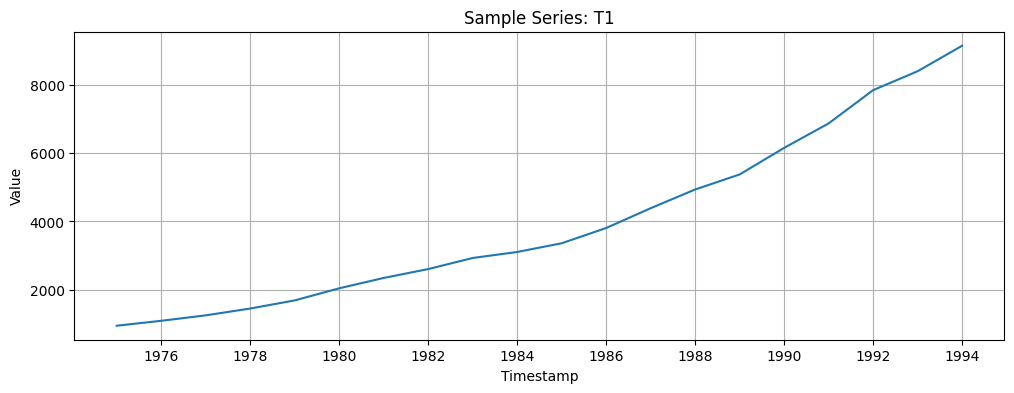

In [10]:
import matplotlib.pyplot as plt

sample_series_id = long_df["series_id"].dropna().unique()[0]
sample_series_df = long_df[long_df["series_id"] == sample_series_id].copy()

plt.figure(figsize=(12, 4))
if sample_series_df["timestamp"].notna().any():
    plt.plot(sample_series_df["timestamp"], sample_series_df["value"])
    plt.xlabel("Timestamp")
else:
    plt.plot(sample_series_df["step_index"], sample_series_df["value"])
    plt.xlabel("Step Index")

plt.ylabel("Value")
plt.title(f"Sample Series: {sample_series_id}")
plt.grid(True)
plt.show()

In [11]:
def split_series_by_horizon(series_values, horizon: int):
    """
    Split one series into train/history and test/future.
    """
    if len(series_values) <= horizon:
        return None, None

    train_values = series_values[:-horizon]
    test_values = series_values[-horizon:]

    return train_values, test_values

In [12]:
horizon = metadata.get("horizon", None)

split_rows = []

for _, row in records_df.iterrows():
    train_values, test_values = split_series_by_horizon(row["series_values"], horizon)

    if train_values is None:
        continue

    split_rows.append({
        "series_id": row.get("series_name"),
        "train_values": train_values,
        "test_values": test_values,
        "train_length": len(train_values),
        "test_length": len(test_values)
    })

split_df = pd.DataFrame(split_rows)

print("Split DataFrame shape:", split_df.shape)
display(split_df.head())

Split DataFrame shape: (645, 5)


,series_id,train_values,test_values,train_length,test_length
0,T1,"[940.66, 1084.86, 1244.98, 1445.02, 1683.17, 2038.15, 2342.52, 2602.45, 2927.87, 3103.96, 3360.27, 3807.63, 4387.88, 4936.99]","[5379.75, 6158.68, 6876.58, 7851.91, 8407.84, 9156.01]",14,6
1,T2,"[1991.05, 2306.4, 2604.0, 2992.3, 3722.08, 5226.62, 5989.46, 5614.62, 5527.0, 5389.8, 5384.4, 3656.2, 4034.8, 4230.0]","[4793.2, 5602.0, 5065.0, 5056.0, 5067.2, 5209.6]",14,6
2,T3,"[1461.57, 1692.5, 2193.82, 2459.68, 3246.8, 4748.86, 5559.46, 5292.42, 5029.4, 4753.6, 4344.6, 2897.4, 3256.4, 3525.2]","[3070.2, 3601.6, 3407.4, 3500.6, 3437.8, 3007.0]",14,6
3,T4,"[744.54, 1105.16, 1417.4, 1838.04, 2337.62, 3094.88, 4280.04, 5070.2, 3675.18, 3667.38, 3808.64, 3114.42, 3847.2, 4632.3]","[4656.0, 5228.52, 5656.72, 5077.02, 5403.4, 5009.52]",14,6
4,T5,"[4977.18, 5248.0, 5370.0, 6184.89, 7137.19, 6743.0, 7298.0, 5260.29, 4898.18, 5392.04, 5117.64, 4332.9, 4620.5, 5488.8]","[5250.9, 4899.2, 4317.9, 4007.9, 4323.4, 4819.4]",14,6


In [13]:
assert len(records_df) > 0, "No series were parsed."
assert len(long_df) > 0, "Long dataframe is empty."
assert metadata.get("horizon") is not None, "Forecast horizon missing."
assert split_df["test_length"].eq(metadata["horizon"]).all(), "Test length does not match horizon."
assert records_df["series_length"].sum() == len(long_df), "Wide-to-long conversion mismatch."

print("Validation checks passed.")

Validation checks passed.


In [14]:
parser_summary = {
    "file_name": tsf_file_path.name,
    "relation": metadata.get("relation"),
    "frequency": metadata.get("frequency"),
    "horizon": metadata.get("horizon"),
    "missing": metadata.get("missing"),
    "equallength": metadata.get("equallength"),
    "num_series": len(records_df),
    "long_rows": len(long_df),
}

pprint(parser_summary)

{'equallength': False,
 'file_name': 'm3_yearly_dataset.tsf',
 'frequency': 'yearly',
 'horizon': 6,
 'long_rows': 18319,
 'missing': False,
 'num_series': 645,
 'relation': 'M3'}


In [15]:
test_files = [
    "m3_quarterly_dataset.tsf",
    "m3_monthly_dataset.tsf",
    "tourism_monthly_dataset.tsf",
    "electricity_weekly_dataset.tsf",
]

base_dir = Path(
    "/Users/kunalgurung/.cache/huggingface/hub/datasets--AutonLab--Timeseries-PILE/snapshots/ea89753da2b451928436adb333c7a2e892461c7d/forecasting/monash"
)

test_results = []

for file_name in test_files:
    file_path = base_dir / file_name
    
    try:
        metadata, attribute_defs, records_df = parse_tsf_file(file_path)
        long_df = convert_to_long_format(records_df, metadata)

        horizon = metadata.get("horizon")
        split_rows = []

        for _, row in records_df.iterrows():
            train_values, test_values = split_series_by_horizon(row["series_values"], horizon)
            if train_values is None:
                continue

            split_rows.append({
                "series_id": row.get("series_name"),
                "train_length": len(train_values),
                "test_length": len(test_values)
            })

        split_df = pd.DataFrame(split_rows)

        result = {
            "file_name": file_name,
            "status": "PASS",
            "frequency": metadata.get("frequency"),
            "horizon": metadata.get("horizon"),
            "num_series": len(records_df),
            "long_rows": len(long_df),
            "all_test_lengths_match_horizon": split_df["test_length"].eq(horizon).all() if not split_df.empty else False
        }

    except Exception as e:
        result = {
            "file_name": file_name,
            "status": "FAIL",
            "frequency": None,
            "horizon": None,
            "num_series": None,
            "long_rows": None,
            "all_test_lengths_match_horizon": None,
            "error": str(e)
        }

    test_results.append(result)

test_results_df = pd.DataFrame(test_results)
display(test_results_df)

,file_name,status,frequency,horizon,num_series,long_rows,all_test_lengths_match_horizon
0,m3_quarterly_dataset.tsf,PASS,quarterly,8,756,37004,True
1,m3_monthly_dataset.tsf,PASS,monthly,18,1428,167562,True
2,tourism_monthly_dataset.tsf,PASS,monthly,24,366,109280,True
3,electricity_weekly_dataset.tsf,PASS,weekly,8,321,50076,True


# Quick Test of tsf_parser.py

In [16]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

print("Project root added to path:", project_root)

Project root added to path: /Users/kunalgurung/Desktop/UTS SEM4/36127/foundation-models-timeseries-forecasting-pile-ghanti


In [17]:
from src.data.tsf_parser import (
    parse_tsf_file,
    convert_to_long_format,
    build_split_dataframe,
)

metadata, attribute_defs, records_df = parse_tsf_file(tsf_file_path)
long_df = convert_to_long_format(records_df, metadata)
split_df = build_split_dataframe(records_df, metadata["horizon"])

print(metadata)
print(records_df.shape, long_df.shape, split_df.shape)

{'relation': 'M3', 'frequency': 'yearly', 'horizon': 6, 'missing': False, 'equallength': False}
(645, 4) (18319, 4) (645, 5)


# Test dataloader.py

In [18]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.data.dataset_loader import (
    list_available_datasets,
    load_monash_dataset,
    build_dataset_summary,
)

print(list_available_datasets())

bundle = load_monash_dataset("m3_monthly")

print(bundle["dataset_key"])
print(bundle["domain"])
print(bundle["metadata"])
print(bundle["records_df"].shape)
print(bundle["long_df"].shape)
print(bundle["split_df"].shape)

summary_df = build_dataset_summary()
summary_df

['electricity_weekly', 'm3_monthly', 'm3_quarterly', 'm3_yearly', 'solar_weekly', 'tourism_monthly', 'tourism_quarterly', 'tourism_yearly']
m3_monthly
economics
{'relation': 'M3', 'frequency': 'monthly', 'horizon': 18, 'missing': False, 'equallength': False}
(1428, 4)
(167562, 4)
(1428, 5)


,dataset_key,domain,file_name,frequency,horizon,missing,equallength,num_series,num_long_rows
0,electricity_weekly,energy,electricity_weekly_dataset.tsf,weekly,8,False,True,321,50076
1,m3_monthly,economics,m3_monthly_dataset.tsf,monthly,18,False,False,1428,167562
2,m3_quarterly,economics,m3_quarterly_dataset.tsf,quarterly,8,False,False,756,37004
3,m3_yearly,economics,m3_yearly_dataset.tsf,yearly,6,False,False,645,18319
4,solar_weekly,energy,solar_weekly_dataset.tsf,weekly,5,False,True,137,7124
5,tourism_monthly,tourism,tourism_monthly_dataset.tsf,monthly,24,False,False,366,109280
6,tourism_quarterly,tourism,tourism_quarterly_dataset.tsf,quarterly,8,False,False,427,42544
7,tourism_yearly,tourism,tourism_yearly_dataset.tsf,yearly,4,False,False,518,12757


# Testing preprocessing.py

In [19]:
from src.data.preprocessing import (
    validate_dataset_bundle,
    preprocess_split_dataframe,
    build_supervised_dataset,
)

bundle = load_monash_dataset("m3_monthly")

validate_dataset_bundle(bundle)

processed_split_df = preprocess_split_dataframe(
    bundle["split_df"],
    fill_missing=True,
    missing_method="ffill",
    scaling=None,
)

print(processed_split_df.shape)
display(processed_split_df.head())

supervised_data = build_supervised_dataset(
    processed_split_df,
    input_window=12,
    use_train_only=True,
)

print("X shape:", supervised_data["X"].shape)
print("y shape:", supervised_data["y"].shape)

(1428, 6)


,series_id,train_values,test_values,train_length,test_length,scaler_info
0,T1,"[2640.0, 2640.0, 2160.0, 4200.0, 3360.0, 2400.0, 3600.0, 1920.0, 4200.0, 4560.0, 480.0, 3720.0, 5640.0, 2880.0, 1800.0, 3120.0, 2400.0, 2520.0, 9000.0, 2640.0, 3120.0, 2880.0, 8760.0, 5160.0, 2160...","[2280.0, 480.0, 5040.0, 1920.0, 840.0, 2520.0, 1560.0, 1440.0, 240.0, 1800.0, 4680.0, 1800.0, 1680.0, 3720.0, 2160.0, 480.0, 2040.0, 1440.0]",50,18,None
1,T2,"[1680.0, 1920.0, 120.0, 1080.0, 840.0, 1440.0, 480.0, 720.0, 4080.0, 1560.0, 480.0, 720.0, 6120.0, 2040.0, 3960.0, 2160.0, 120.0, 1200.0, 1080.0, 1080.0, 1080.0, 2160.0, 240.0, 1440.0, 1200.0, 156...","[1440.0, 840.0, 1440.0, 1560.0, 1080.0, 360.0, 960.0, 1320.0, 1080.0, 1680.0, 1080.0, 840.0, 840.0, 600.0, 1320.0, 1320.0, 2280.0, 1440.0]",50,18,None
2,T3,"[1140.0, 720.0, 4860.0, 1200.0, 3150.0, 2130.0, 1800.0, 2010.0, 2880.0, 1650.0, 1740.0, 4440.0, 7410.0, 3000.0, 4410.0, 4980.0, 2040.0, 3000.0, 5430.0, 4650.0, 2520.0, 2250.0, 2100.0, 5730.0, 2550...","[6540.0, 4920.0, 1710.0, 3420.0, 5910.0, 6720.0, 4650.0, 2550.0, 8640.0, 7680.0, 6720.0, 5190.0, 5190.0, 5910.0, 4800.0, 5640.0, 5790.0, 4230.0]",50,18,None
3,T4,"[180.0, 940.0, 2040.0, 800.0, 1000.0, 520.0, 500.0, 400.0, 1760.0, 1520.0, 1400.0, 1840.0, 3360.0, 220.0, 6000.0, 3160.0, 1060.0, 820.0, 2860.0, 440.0, 1880.0, 220.0, 1460.0, 4620.0, 1360.0, 3220....","[7420.0, 4260.0, 2740.0, 3200.0, 7140.0, 6960.0, 5760.0, 2280.0, 12300.0, 8800.0, 9660.0, 5860.0, 6600.0, 8100.0, 7760.0, 6940.0, 8020.0, 6400.0]",50,18,None
4,T5,"[2000.0, 1550.0, 4450.0, 3050.0, 3050.0, 2250.0, 2200.0, 2450.0, 4900.0, 5300.0, 600.0, 12050.0, 4050.0, 1900.0, 3200.0, 7400.0, 10650.0, 9850.0, 4000.0, 11500.0, 2750.0, 5700.0, 3900.0, 9200.0, 3...","[7350.0, 6500.0, 2700.0, 8700.0, 9250.0, 10250.0, 9550.0, 6450.0, 9800.0, 12450.0, 10050.0, 8400.0, 10000.0, 10950.0, 10700.0, 8800.0, 7550.0, 8800.0]",50,18,None


X shape: (100446, 12)
y shape: (100446, 18)


In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.data.dataset_loader import (
    list_available_datasets,
    list_available_domains,
    list_datasets_by_domain,
    list_datasets_by_frequency,
    build_registry_table,
    build_dataset_summary,
    load_monash_dataset,
)

print(list_available_domains())
print(list_datasets_by_domain("finance"))
print(list_datasets_by_domain("energy"))
print(list_datasets_by_domain("retail"))
print(list_datasets_by_frequency("weekly"))

display(build_registry_table())

bundle = load_monash_dataset("bitcoin")
print(bundle["dataset_key"])
print(bundle["domain"])
print(bundle["frequency"])
print(bundle["metadata"])
print(bundle["records_df"].shape)
print(bundle["long_df"].shape)
print(bundle["split_df"].shape)

summary_df = build_dataset_summary([
    "bitcoin",
    "fred_md",
    "m4_quarterly",
    "australian_electricity_demand",
    "electricity_weekly",
    "solar_10_minutes",
    "nn5_daily",
    "dominick",
    "car_parts",
])
display(summary_df)

['energy', 'finance', 'retail']
['bitcoin', 'fred_md', 'm3_monthly', 'm3_quarterly', 'm3_yearly', 'm4_quarterly']
['australian_electricity_demand', 'electricity_hourly', 'electricity_weekly', 'solar_10_minutes', 'solar_weekly']
['car_parts', 'dominick', 'nn5_daily', 'nn5_weekly']
['dominick', 'electricity_weekly', 'nn5_weekly', 'solar_weekly']


,dataset_key,domain,frequency,file_name,description
0,solar_10_minutes,energy,10_minutes,solar_10_minutes_dataset.tsf,High-frequency solar generation dataset with 1...
1,australian_electricity_demand,energy,hourly,australian_electricity_demand_dataset.tsf,Australian electricity demand time series.
2,electricity_hourly,energy,hourly,electricity_hourly_dataset.tsf,Hourly electricity load dataset.
3,electricity_weekly,energy,weekly,electricity_weekly_dataset.tsf,Weekly electricity consumption/demand dataset.
4,solar_weekly,energy,weekly,solar_weekly_dataset.tsf,Weekly solar generation dataset.
5,bitcoin,finance,daily,bitcoin_dataset_without_missing_values.tsf,Cryptocurrency price series with strong volati...
6,fred_md,finance,monthly,fred_md_dataset.tsf,US macroeconomic indicators from the FRED-MD c...
7,m3_monthly,finance,monthly,m3_monthly_dataset.tsf,Monthly benchmark dataset from the M3 forecast...
8,m3_quarterly,finance,quarterly,m3_quarterly_dataset.tsf,Quarterly benchmark dataset from the M3 foreca...
9,m4_quarterly,finance,quarterly,m4_quarterly_dataset.tsf,Quarterly benchmark dataset from the M4 foreca...


bitcoin
finance
daily
{'relation': 'bitcoin_technological_factors', 'frequency': 'daily', 'missing': False, 'equallength': False, 'resolved_horizon': 30}
(18, 4)
(75364, 4)
(18, 5)


ValueError: No forecast horizon found for dataset 'fred_md'. Add a 'default_horizon' to the registry or inspect the dataset metadata.

## Parser Conclusion

This notebook successfully:
- parsed a Monash `.tsf` forecasting dataset
- extracted metadata and per-series values
- converted the file into both wide and long pandas formats
- generated train/test splits using the forecast horizon

This parser can now be reused for selected datasets across the economics, tourism, and energy domains.